# Insurance Claims Fraud Detection — Exploratory Data Analysis
## University of Ghana | DSA Final Year Project | AY 2025/2026

---

This notebook covers **Point 1 — Understanding the Dataset** and **Point 2 — Data Structure and Quality Checks**.

Every code cell does real work on the data. Every markdown cell below the code explains line-by-line what was done and why.

Run cells top to bottom.

---

---
# POINT 1 — Understanding the Dataset

> **Goal:** Before writing a single analysis line, we establish *what* this dataset is,
> *who* it describes, *what* we are predicting, and *what rules* govern its use.
> We answer these questions with code — not assumptions.

---

## Step 1.1 — Load the Dataset and Get First Impressions

We load the data and immediately ask the most basic question: what does it look like?
We start completely blind — letting the data speak before we impose any assumptions.

In [1]:
# ── IMPORTS ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── DISPLAY SETTINGS ──────────────────────────────────────────
# These settings tell pandas to never hide columns or cut off values
pd.set_option('display.max_columns', None)   # show ALL columns
pd.set_option('display.max_rows', 100)        # show up to 100 rows
pd.set_option('display.width', 1000)          # wide output, no wrapping
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places

# ── LOAD DATA ─────────────────────────────────────────────────
df = pd.read_csv('../data/cleaned/insurance_claims_cleaned.csv')
# If your file is in a subfolder: pd.read_csv('data/insurance_claims_cleaned.csv')

print("Dataset loaded.")
print(f"Shape: {df.shape[0]} rows  x  {df.shape[1]} columns")

Dataset loaded.
Shape: 1000 rows  x  39 columns


### Line-by-line explanation

- `import pandas as pd` — loads pandas, the core library for working with tables in Python. We alias it `pd` so we type `pd.` not `pandas.` everywhere.
- `import numpy as np` — numerical operations library. Needed for array maths later.
- `warnings.filterwarnings('ignore')` — suppresses non-critical warnings that clutter output.
- `pd.set_option('display.max_columns', None)` — by default pandas hides columns when there are many. `None` means 'show all, no limit'. Critical for a 39-column dataset.
- `pd.read_csv(...)` — reads the CSV file from disk into a DataFrame. A DataFrame is Python's equivalent of an Excel spreadsheet: rows and columns you can query and transform.
- `df.shape` — returns a tuple `(rows, columns)`. This is always the very first check — you confirm the file loaded completely and nothing was truncated.

## Step 1.2 — First and Last 5 Rows

Before any analysis, look at the actual data. This single step often reveals more than 20 lines of summary code — you see formatting, you see real values, you spot obvious issues immediately.

In [2]:
# Show first 5 rows exactly as they loaded from disk
# .head() returns the first 5 rows by default
# Use df.head(10) for 10 rows, df.head(20) for 20
print("=== FIRST 5 ROWS ===")
df.head()

=== FIRST 5 ROWS ===


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital_gains,capital_loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,Male,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,1
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,Male,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,Not Applicable,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,NO,0,0,NO,5070,780,780,3510,Mercedes,E400,2007,1
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,Female,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,0
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,Female,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,NO,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,1
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,Male,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,Not Applicable,Minor Damage,Police,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,0


In [3]:
# Show the LAST 5 rows
# Head + tail together confirm the file is not sorted, truncated, or cut off at the end
print("=== LAST 5 ROWS ===")
df.tail()

=== LAST 5 ROWS ===


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital_gains,capital_loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,Female,Masters,craft-repair,paintball,unmarried,0,0,2015-02-22,Single Vehicle Collision,Front Collision,Minor Damage,Fire,NC,Northbrook,6045 Andromedia St,20,1,YES,0,1,NO,87200,17440,8720,61040,Honda,Accord,2006,0
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,Female,PhD,prof-specialty,sleeping,wife,70900,0,2015-01-24,Single Vehicle Collision,Rear Collision,Major Damage,Fire,SC,Northbend,3092 Texas Drive,23,1,YES,2,3,NO,108480,18080,18080,72320,Volkswagen,Passat,2015,0
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,Female,Masters,armed-forces,bungie-jumping,other-relative,35100,0,2015-01-23,Multi-vehicle Collision,Side Collision,Minor Damage,Police,NC,Arlington,7629 5th St,4,3,NO,2,3,YES,67500,7500,7500,52500,Suburu,Impreza,1996,0
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,Male,Associate,handlers-cleaners,base-jumping,wife,0,0,2015-02-26,Single Vehicle Collision,Rear Collision,Major Damage,Other,NY,Arlington,6128 Elm Lane,2,1,NO,0,1,YES,46980,5220,5220,36540,Audi,A5,1998,0
999,456,60,556080,1996-11-11,OH,250/500,1000,766.19,0,612260,Female,Associate,sales,kayaking,husband,0,0,2015-02-26,Parked Car,Not Applicable,Minor Damage,Police,WV,Columbus,1416 Cherokee Ridge,6,1,NO,0,3,NO,5060,460,920,3680,Mercedes,E400,2007,0


### What to look for when reading these rows

- Do the column names make intuitive sense?
- Are there obviously wrong values (negative age, claim amount of zero)?
- Do text columns have consistent formatting (all caps? mixed case? random spaces)?
- Are date columns stored as real dates or as plain text strings?
- Which column looks like it could be the fraud label?

**Why look at both head AND tail?** If the file was exported sorted by date or ID, the first and last rows may look very different. Seeing both ends confirms the data spans the full range expected.

## Step 1.3 — Inventory Every Column

We build a structured reference table of every column: its position, data type, how many values it has, how many are missing, how many are unique, and a real sample value.

In [4]:
col_inventory = pd.DataFrame({
    'position'  : range(1, len(df.columns) + 1),
    # Column number starting at 1. More readable than 0-indexed.

    'column'    : df.columns,
    # The exact column name as it appears in the file.

    'dtype'     : df.dtypes.values,
    # The data type pandas assigned when loading.
    # int64 = whole numbers | float64 = decimals | object = text/string

    'non_null'  : df.count().values,
    # Number of rows that have a value (not missing).
    # Should equal 1000 for every column in a complete dataset.

    'null_count': df.isnull().sum().values,
    # Number of missing values per column.
    # .isnull() returns True/False per cell. .sum() counts the Trues.

    'n_unique'  : [df[c].nunique() for c in df.columns],
    # Number of distinct values.
    # 2 unique = likely binary (YES/NO). 1000 unique = likely an ID or address.

    'sample_val': [str(df[c].dropna().iloc[0]) if df[c].dropna().shape[0] > 0
                   else 'ALL NULL' for c in df.columns]
    # The first real (non-null) value. Shows you what the data looks like in practice.
})

print(f"Total columns: {len(df.columns)}")
print()
print(col_inventory.to_string(index=False))
# .to_string(index=False) prints the full table without the row numbers on the left

Total columns: 39

 position                      column   dtype  non_null  null_count  n_unique               sample_val
        1          months_as_customer   int64      1000           0       391                      328
        2                         age   int64      1000           0        46                       48
        3               policy_number   int64      1000           0      1000                   521585
        4            policy_bind_date     str      1000           0       951               2014-10-17
        5                policy_state     str      1000           0         3                       OH
        6                  policy_csl     str      1000           0         3                  250/500
        7           policy_deductable   int64      1000           0         3                     1000
        8       policy_annual_premium float64      1000           0       991                  1406.91
        9              umbrella_limit   int64      100

### How to read this table

- **dtype `object`** — means text/string. Could also mean a column pandas couldn't parse (e.g. dates stored as text, or ZIP codes stored as numbers with letters).
- **null_count > 0** — that column has missing data. Will be handled in Step 2.8.
- **n_unique = 2** — likely a binary YES/NO or 0/1 column.
- **n_unique = 1000** — every row has a different value. This is an identifier column (no predictive use).
- **n_unique = 3 or 4** — likely a low-cardinality categorical (e.g. policy_state has 3 states).

This table is your **column reference dictionary** for the entire EDA.

## Step 1.4 — Build a Data Dictionary

A data dictionary explains the **business meaning** of every column. Column names like `policy_csl` or `umbrella_limit` are not self-explanatory. Without knowing what a column means you cannot decide:

- Whether its values are valid (is a negative `umbrella_limit` an error or a liability cap?)
- Whether it leaks information about the label (was it filled *after* the fraud decision?)
- Whether it is useful for modelling or should be dropped

The dictionary is built from column names, sample values, and auto insurance domain knowledge.

In [5]:
# Each entry: column_name : (category, plain-English business meaning)
data_dict = {
    'months_as_customer'       : ('Policy/Customer',
                                  'How long the insured has been a customer, in months'),
    'age'                      : ('Policy/Customer',
                                  'Age of the primary insured person in years'),
    'policy_number'            : ('Identifier',
                                  'Unique ID for each policy — primary key. Drop before modelling.'),
    'policy_bind_date'         : ('Policy/Customer',
                                  'Date the policy was originally activated (bound)'),
    'policy_state'             : ('Policy/Customer',
                                  'US state where policy was issued: OH, IN, or IL'),
    'policy_csl'               : ('Policy/Customer',
                                  'Combined Single Limit — max payout per incident. Format: per-person/per-accident e.g. 250/500 = $250k per person $500k per accident'),
    'policy_deductable'        : ('Policy/Customer',
                                  'Amount insured pays before insurance pays. Only 3 values: $500 $1000 $2000'),
    'policy_annual_premium'    : ('Policy/Customer',
                                  'Yearly amount the insured pays for the policy in USD'),
    'umbrella_limit'           : ('Policy/Customer',
                                  'Extra liability coverage beyond standard policy. 0 = no umbrella. Negatives = liability caps (valid by domain knowledge).'),
    'insured_zip'              : ('PII/Demographics',
                                  'ZIP code of insured — geographic quasi-identifier. Privacy-sensitive. Loaded as int but is actually a label NOT a number.'),
    'insured_sex'              : ('PII/Demographics',
                                  'Gender of the insured: Male or Female'),
    'insured_education_level'  : ('PII/Demographics',
                                  'Highest education level: Associate Bachelor Master PhD MD'),
    'insured_occupation'       : ('PII/Demographics',
                                  'Occupation category e.g. exec-managerial craft-repair sales'),
    'insured_hobbies'          : ('PII/Demographics',
                                  'Self-reported hobby e.g. chess cross-fit sleeping'),
    'insured_relationship'     : ('PII/Demographics',
                                  'Insured persons relationship to policy holder e.g. husband own-child unmarried'),
    'capital_gains'            : ('Financial',
                                  'Insured capital gains in USD at time of claim. 0 = none reported'),
    'capital_loss'             : ('Financial',
                                  'Insured capital losses in USD. Stored as negative values. 0 = none.'),
    'incident_date'            : ('Incident',
                                  'Date the incident occurred — loaded as string must convert to datetime'),
    'incident_type'            : ('Incident',
                                  'Category: Single Vehicle Collision / Multi-vehicle Collision / Vehicle Theft / Parked Car'),
    'collision_type'           : ('Incident',
                                  'Direction of impact: Front/Rear/Side Collision. Not Applicable for theft or parked car.'),
    'incident_severity'        : ('Incident',
                                  'Assessed damage level: Trivial Damage / Minor Damage / Major Damage / Total Loss'),
    'authorities_contacted'    : ('Incident',
                                  'Which authority responded: Police Fire Ambulance Other None'),
    'incident_state'           : ('Incident',
                                  'US state where incident occurred — may differ from policy state'),
    'incident_city'            : ('Incident',
                                  'City where incident occurred'),
    'incident_location'        : ('Incident',
                                  'Street address — near-unique per row. No predictive value. Drop before modelling.'),
    'incident_hour_of_the_day' : ('Incident',
                                  'Hour of day the incident occurred (0-23, 24-hour clock)'),
    'number_of_vehicles_involved': ('Incident',
                                  'How many vehicles were involved (1-4)'),
    'property_damage'          : ('Incident',
                                  'Was non-vehicle property damaged? YES or NO'),
    'bodily_injuries'          : ('Incident',
                                  'Number of people reporting bodily injuries (0-2)'),
    'witnesses'                : ('Incident',
                                  'Number of witnesses at the scene (0-3)'),
    'police_report_available'  : ('Incident',
                                  'Was a police report filed and available? YES or NO'),
    'total_claim_amount'       : ('Claim/Financial',
                                  'Total amount claimed USD. EQUALS injury+property+vehicle — algebraically redundant.'),
    'injury_claim'             : ('Claim/Financial',
                                  'Amount claimed for bodily injuries in USD'),
    'property_claim'           : ('Claim/Financial',
                                  'Amount claimed for property (non-vehicle) damage in USD'),
    'vehicle_claim'            : ('Claim/Financial',
                                  'Amount claimed for vehicle damage in USD'),
    'auto_make'                : ('Vehicle',
                                  'Car manufacturer e.g. Toyota BMW Ford Mercedes'),
    'auto_model'               : ('Vehicle',
                                  'Specific car model e.g. Camry E400 RAM'),
    'auto_year'                : ('Vehicle',
                                  'Year the car was manufactured'),
    'fraud_reported'           : ('*** TARGET ***',
                                  '*** TARGET VARIABLE *** 1 = fraudulent claim  0 = legitimate claim'),
}

dict_df = pd.DataFrame(
    [{'Column': col, 'Category': cat, 'Business Meaning': meaning}
     for col, (cat, meaning) in data_dict.items()]
)
# We build a DataFrame from the dictionary so it prints as a clean table

print(f"Data dictionary: {len(dict_df)} columns documented")
print()
print(dict_df.to_string(index=False))

Data dictionary: 39 columns documented

                     Column         Category                                                                                                                    Business Meaning
         months_as_customer  Policy/Customer                                                                                 How long the insured has been a customer, in months
                        age  Policy/Customer                                                                                          Age of the primary insured person in years
              policy_number       Identifier                                                                     Unique ID for each policy — primary key. Drop before modelling.
           policy_bind_date  Policy/Customer                                                                                    Date the policy was originally activated (bound)
               policy_state  Policy/Customer                               

### How the data dictionary was built

1. **Self-explanatory columns** (`age`, `witnesses`, `bodily_injuries`) — readable directly from the name.
2. **Sample values guided understanding** — seeing `policy_csl` contains `250/500` tells us it is a Combined Single Limit, a standard US auto insurance term.
3. **Insurance domain knowledge** — `umbrella_limit`, `deductable`, and CSL require knowing what these mean in an insurance context. If you don't know, this is the point where you consult the business stakeholder or the data provider's documentation.
4. **The target variable** — `fraud_reported` contains only 0 and 1, is the last column, and its name directly states what it measures. This is our label.

> **Professional rule:** Never begin modelling without a data dictionary. Without it you cannot catch data leakage, cannot identify PII, and cannot make sound feature engineering decisions.

## Step 1.5 — Write the Business Objective

In [6]:
print("=" * 65)
print("BUSINESS OBJECTIVE")
print("=" * 65)
print()
print("PROBLEM:")
print("  Insurance fraud occurs when a claimant deliberately fabricates")
print("  or exaggerates an auto insurance incident (accident, theft,")
print("  damage) to receive a payout they are not entitled to.")
print()
print("OBJECTIVE:")
print("  Build a classification model that predicts whether a submitted")
print("  insurance claim is fraudulent (fraud_reported=1) or legitimate")
print("  (fraud_reported=0), enabling the insurer to flag high-risk")
print("  claims for investigation BEFORE authorising payout.")
print()
print("COST ASYMMETRY (drives metric choice):")
print("  Missing a fraud   (False Negative) : insurer pays fraudulent")
print("                                        claim — direct loss")
print("  Flagging legit    (False Positive)  : customer delay only")
print("                                        — recoverable")
print()
print("THEREFORE: RECALL on the fraud class is the primary metric.")
print("A model catching 80% of fraud with 30% FP rate is far more")
print("valuable than one catching 50% of fraud with 5% FP rate.")
print("=" * 65)

BUSINESS OBJECTIVE

PROBLEM:
  Insurance fraud occurs when a claimant deliberately fabricates
  or exaggerates an auto insurance incident (accident, theft,
  damage) to receive a payout they are not entitled to.

OBJECTIVE:
  Build a classification model that predicts whether a submitted
  insurance claim is fraudulent (fraud_reported=1) or legitimate
  (fraud_reported=0), enabling the insurer to flag high-risk
  claims for investigation BEFORE authorising payout.

COST ASYMMETRY (drives metric choice):
  Missing a fraud   (False Negative) : insurer pays fraudulent
                                        claim — direct loss
  Flagging legit    (False Positive)  : customer delay only
                                        — recoverable

THEREFORE: RECALL on the fraud class is the primary metric.
A model catching 80% of fraud with 30% FP rate is far more
valuable than one catching 50% of fraud with 5% FP rate.


### Why write the objective as printed code output?

When this notebook is re-run or shared with a supervisor or examiner, the business objective appears inline with the analysis — not buried in a comment. It forces the analyst to commit in writing to *what they are solving* before they produce a single chart, preventing scope creep later.

## Step 1.6 — Identify and Confirm the Target Variable

We confirm the target variable programmatically — not by assumption. We check what values it contains, whether it is truly binary, and what the class balance looks like. The class balance determines which evaluation metrics are valid for this problem.

Target column : 'fraud_reported'
Data type     : int64
Unique values : [np.int64(0), np.int64(1)]

Class distribution:
  0 = Non-Fraud :   753 claims  (75.3%)
  1 = Fraud     :   247 claims  (24.7%)
  Imbalance     : 3.05:1  (non-fraud to fraud)

NULL CLASSIFIER WARNING:
  A model that always predicts Non-Fraud scores 75.3% accuracy.
  This makes raw accuracy a completely useless metric here.
  Primary metrics to use instead: Recall, F1-Score, AUPRC


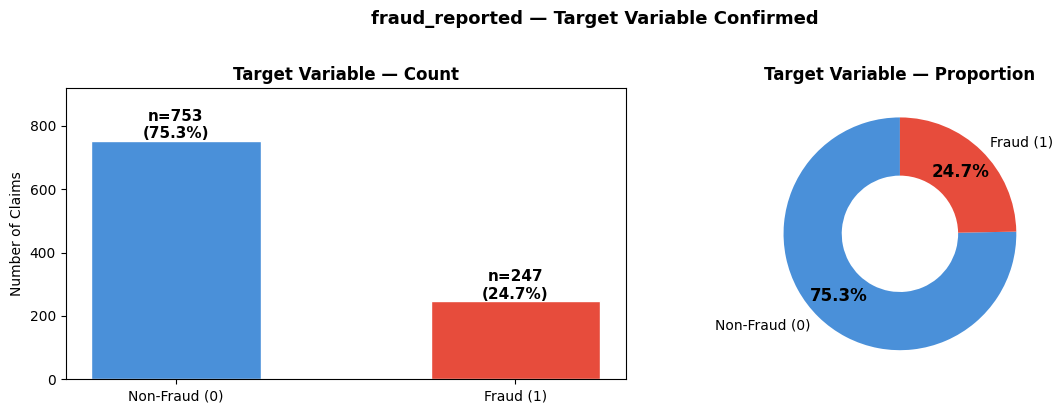

Chart saved: 01_target_distribution.png


In [7]:
TARGET = 'fraud_reported'
# We store the target column name in a variable.
# If the column were ever renamed we only change it in this one place
# and every cell below automatically uses the new name.

print(f"Target column : {repr(TARGET)}")
print(f"Data type     : {df[TARGET].dtype}")
print(f"Unique values : {sorted(df[TARGET].unique())}")
print()

# Count how many rows belong to each class
vc     = df[TARGET].value_counts().sort_index()
# .value_counts() counts how many times each distinct value appears.
# .sort_index() sorts by value (0 first, then 1) so output is consistent.

vc_pct = df[TARGET].value_counts(normalize=True).sort_index() * 100
# normalize=True converts raw counts to proportions (0.0 to 1.0).
# Multiplying by 100 converts to percentages.

print("Class distribution:")
print(f"  0 = Non-Fraud : {vc[0]:>5} claims  ({vc_pct[0]:.1f}%)")
print(f"  1 = Fraud     : {vc[1]:>5} claims  ({vc_pct[1]:.1f}%)")
print(f"  Imbalance     : {vc[0]/vc[1]:.2f}:1  (non-fraud to fraud)")
print()
print("NULL CLASSIFIER WARNING:")
print(f"  A model that always predicts Non-Fraud scores {vc_pct[0]:.1f}% accuracy.")
print( "  This makes raw accuracy a completely useless metric here.")
print( "  Primary metrics to use instead: Recall, F1-Score, AUPRC")

# ── VISUALISATION ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#4A90D9', '#E74C3C']

# Left panel — bar chart of counts
bars = axes[0].bar(['Non-Fraud (0)', 'Fraud (1)'], vc.values,
                    color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Target Variable — Count', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Number of Claims')
axes[0].set_ylim(0, max(vc.values) * 1.22)
for bar, n, p in zip(bars, vc.values, vc_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 8,
                 f'n={n}\n({p:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

# Right panel — donut chart of proportions
wedges, texts, autotexts = axes[1].pie(
    vc.values,
    labels=['Non-Fraud (0)', 'Fraud (1)'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5)   # width<1 makes it a donut not a pie
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[1].set_title('Target Variable — Proportion', fontweight='bold', fontsize=12)

plt.suptitle('fraud_reported — Target Variable Confirmed',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 01_target_distribution.png")

### What this tells us

- **Binary classification problem** — only two values (0 and 1). This is not multi-class or regression.
- **Class imbalance: 75.3% vs 24.7%** — a 3.05:1 ratio. Moderate but meaningful. Will require oversampling strategy (SMOTE/Random) in Section 14.
- **The null classifier trap** — predicting Non-Fraud every time gives 75.3% accuracy. This is why we must use Recall, F1-Score, and AUPRC as our primary metrics instead.
- **The 24.7% fraud rate is higher than real-world auto insurance** (typically 1–5%). This is a synthetic research dataset deliberately oversampled so models have enough fraud examples to learn from.

## Step 1.7 — Confirm the Unit of Analysis

The unit of analysis answers: *what does one row represent?*
This is not always obvious. One row could be one claim, one customer, one policy, or one transaction line item on an invoice. Getting this wrong corrupts every aggregation.

In [8]:
print("=== UNIT OF ANALYSIS ===")
print()

n_rows          = len(df)
# len(df) returns the total number of rows in the DataFrame

n_unique_policy = df['policy_number'].nunique()
# .nunique() counts how many DISTINCT values exist in the column.
# If this equals n_rows, every row has a different policy_number
# — confirming it is a true unique identifier.

print(f"Total rows              : {n_rows}")
print(f"Unique policy_number    : {n_unique_policy}")
print()

if n_unique_policy == n_rows:
    print("CONFIRMED: policy_number is unique for every row.")
    print("Unit of analysis = ONE INSURANCE CLAIM PER ROW")
    print()
    print("Consequences for the project:")
    print("  - Each row is one independent claim event")
    print("  - One customer does not appear multiple times")
    print("  - Standard random stratified train/test split is valid")
    print("  - No need for group-aware cross-validation")
    print("  - Aggregations (mean, count) are per-claim, not per-customer")
else:
    repeated = n_rows - n_unique_policy
    print(f"WARNING: {repeated} policy numbers appear more than once.")
    print("One customer filed multiple claims — investigate further.")
    dupes = df[df.duplicated(subset='policy_number', keep=False)]
    print(dupes[['policy_number','incident_date','fraud_reported']].head(10))

=== UNIT OF ANALYSIS ===

Total rows              : 1000
Unique policy_number    : 1000

CONFIRMED: policy_number is unique for every row.
Unit of analysis = ONE INSURANCE CLAIM PER ROW

Consequences for the project:
  - Each row is one independent claim event
  - One customer does not appear multiple times
  - Standard random stratified train/test split is valid
  - No need for group-aware cross-validation
  - Aggregations (mean, count) are per-claim, not per-customer


### Why the unit of analysis matters so much

If one customer appeared in multiple rows (multiple claims), then:

- Calculating the average age of fraud claimants would be biased toward prolific claimants who appear many times
- The train/test split would need to be done by customer — not by row — to prevent the same customer from appearing in both sets (data leakage)
- You would need to engineer multi-claim features (e.g. 'number of claims this customer has filed')

In this dataset, `policy_number` is unique per row — confirming each row is one independent claim with no customer leakage risk.

## Step 1.8 — Record Dataset Size in Full Detail

In [9]:
print("=== DATASET SIZE ===")
print()
print(f"Rows (claims)    : {df.shape[0]:,}")
# :, formats the number with commas as thousand separators: 1000 -> 1,000

print(f"Columns          : {df.shape[1]}")
print()

# Break columns down by data type
print("Column types breakdown:")
type_summary = df.dtypes.value_counts()
# .dtypes gives the type of every column.
# .value_counts() then counts how many columns have each type.

for dtype, count in type_summary.items():
    col_names = df.select_dtypes(include=[dtype]).columns.tolist()
    # select_dtypes(include=[dtype]) returns only columns of that type
    print(f"  {str(dtype):<12}: {count} columns")
    for c in col_names:
        print(f"             - {c}")
    print()

# Memory usage
mem = df.memory_usage(deep=True).sum()
# deep=True measures actual memory used by string contents
# (not just the pointer size). Much more accurate for text-heavy datasets.
print(f"Memory footprint : {mem/1024:.1f} KB  ({mem/1024**2:.2f} MB)")
print()
print("Scale assessment : SMALL dataset (<10,000 rows)")
print("  All operations run instantly.")
print("  Every row can be manually inspected if needed.")
print("  No sampling, chunking, or distributed computing required.")

=== DATASET SIZE ===

Rows (claims)    : 1,000
Columns          : 39

Column types breakdown:
  str         : 20 columns
             - policy_bind_date
             - policy_state
             - policy_csl
             - insured_sex
             - insured_education_level
             - insured_occupation
             - insured_hobbies
             - insured_relationship
             - incident_date
             - incident_type
             - collision_type
             - incident_severity
             - authorities_contacted
             - incident_state
             - incident_city
             - incident_location
             - property_damage
             - police_report_available
             - auto_make
             - auto_model

  int64       : 18 columns
             - months_as_customer
             - age
             - policy_number
             - policy_deductable
             - umbrella_limit
             - insured_zip
             - capital_gains
             - capital_los

## Step 1.9 — Identify Key Identifiers

Identifier columns label or name each record. They must be found early because:

1. They must be **dropped before modelling** — they carry no predictive signal
2. They must be **checked for uniqueness** — a non-unique ID signals a data problem
3. They may be **required for joins** if additional data sources are added later

In [10]:
print("=== KEY IDENTIFIERS ===")
print()

# Define each potential identifier, why it matters, and what to do with it
identifiers = {
    'policy_number'  : 'Primary key. Unique per claim. Drop before modelling.',
    'insured_zip'    : 'ZIP code. Geographic quasi-identifier. Loaded as int but is a label not a number.',
    'incident_location': 'Street address. Near-unique per row. No predictive value. Drop.',
    'incident_city'  : 'City. Lower cardinality. Usable as grouped geographic feature.',
    'incident_state' : 'State. Low cardinality (6 values). Useful for modelling.',
    'policy_state'   : 'Policy state. Low cardinality (3 values). Useful for modelling.',
}

for col, note in identifiers.items():
    if col in df.columns:
        n_uniq   = df[col].nunique()
        uniq_pct = n_uniq / len(df) * 100
        # What fraction of rows have a unique value for this column?
        # 100% unique = every row is different = likely an ID column
        print(f"  {col}")
        print(f"    Unique values : {n_uniq:,} / {len(df):,}  ({uniq_pct:.1f}% of rows are unique)")
        print(f"    Note          : {note}")
        print()

print("DROP BEFORE MODELLING:")
for c in ['policy_number', 'incident_location']:
    print(f"  -> {c}")
print()
print("HIGH-CARDINALITY (use with care in modelling):")
print(f"  -> insured_zip   : {df['insured_zip'].nunique()} unique ZIP codes")
print(f"  -> incident_city : {df['incident_city'].nunique()} unique cities")

=== KEY IDENTIFIERS ===

  policy_number
    Unique values : 1,000 / 1,000  (100.0% of rows are unique)
    Note          : Primary key. Unique per claim. Drop before modelling.

  insured_zip
    Unique values : 995 / 1,000  (99.5% of rows are unique)
    Note          : ZIP code. Geographic quasi-identifier. Loaded as int but is a label not a number.

  incident_location
    Unique values : 1,000 / 1,000  (100.0% of rows are unique)
    Note          : Street address. Near-unique per row. No predictive value. Drop.

  incident_city
    Unique values : 7 / 1,000  (0.7% of rows are unique)
    Note          : City. Lower cardinality. Usable as grouped geographic feature.

  incident_state
    Unique values : 7 / 1,000  (0.7% of rows are unique)
    Note          : State. Low cardinality (6 values). Useful for modelling.

  policy_state
    Unique values : 3 / 1,000  (0.3% of rows are unique)
    Note          : Policy state. Low cardinality (3 values). Useful for modelling.

DROP BEFOR

### Why uniqueness percentage matters

- **100% unique** (`policy_number`, `incident_location`) — every row has a different value. The model cannot learn anything general from a value it has never seen before. Drop these.
- **~50–90% unique** (`insured_zip`, `incident_city`) — high cardinality categoricals. May contain geographic fraud patterns but risk overfitting. Use with care.
- **Low % unique** (`policy_state` with 3 values, `incident_severity` with 4) — true categoricals. Safe and useful for modelling.

## Step 1.10 — Data Sources and Time Coverage

This step completes the one unchecked item from the original checklist. We extract time coverage directly from the data — not from documentation.

=== DATA SOURCES AND TIME COVERAGE ===

  Incident dates  :
    Earliest : 2015-01-01
    Latest   : 2015-03-01
    Span     : 59 days  (~0 yrs 1 months)

  Policy bind dates:
    Earliest : 1990-01-08
    Latest   : 2015-02-22
    Span     : 9176 days  (~25 yrs 1 months)



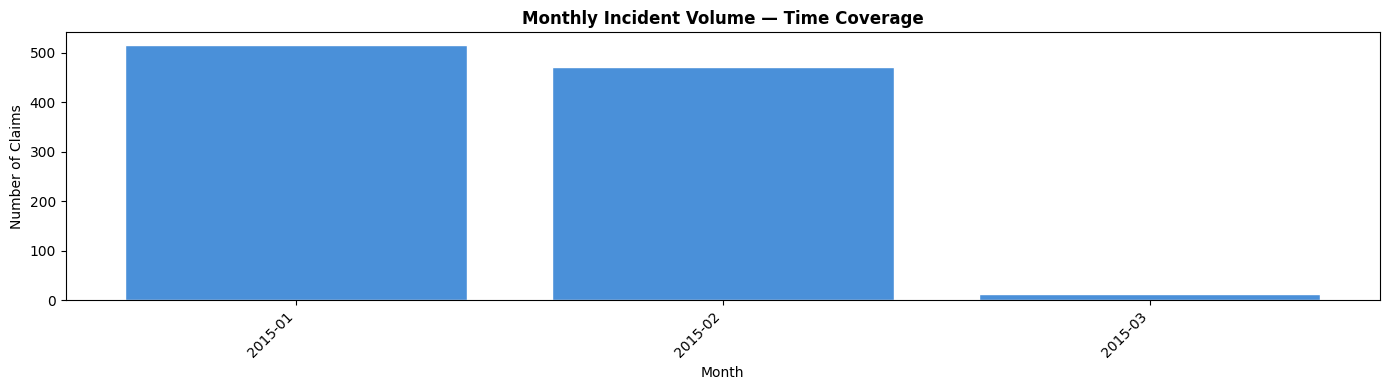

Data source:
  Aqqad (2023) — Mendeley Data, synthetic auto insurance claims
  States covered  : OH (Ohio), IN (Indiana), IL (Illinois)
  Dataset nature  : Synthetic — derived from real claim patterns
                    for academic and research use

Implication for modelling:
  All incidents are from approx. 2015 — cross-sectional snapshot.
  No time-based train/test split needed.
  Use random stratified split instead.


In [11]:
print("=== DATA SOURCES AND TIME COVERAGE ===")
print()

# Convert date columns from strings to real datetime objects
df['incident_date_dt']    = pd.to_datetime(df['incident_date'])
df['policy_bind_date_dt'] = pd.to_datetime(df['policy_bind_date'])
# pd.to_datetime() parses text like '2015-01-25' into a Python date object.
# Without this, .min() and .max() would sort alphabetically.
# '2015-01-25' < '2015-02-01' works alphabetically by coincidence for ISO dates,
# but '2015-12-01' > '2015-09-15' fails alphabetically. Always convert properly.

date_cols = [
    ('Incident dates  ', 'incident_date_dt'),
    ('Policy bind dates', 'policy_bind_date_dt'),
]
for label, col in date_cols:
    s = df[col]
    span = (s.max() - s.min()).days
    # Subtracting two datetime objects gives a timedelta. .days extracts the integer.
    print(f"  {label}:")
    print(f"    Earliest : {s.min().date()}")
    print(f"    Latest   : {s.max().date()}")
    print(f"    Span     : {span} days  (~{span//365} yrs {(span%365)//30} months)")
    print()

# Monthly incident volume chart
fig, ax = plt.subplots(figsize=(14, 4))
monthly = df['incident_date_dt'].dt.to_period('M').value_counts().sort_index()
# .dt.to_period('M') converts each datetime to its year-month period (e.g. 2015-01).
# .value_counts() counts how many incidents per month.
# .sort_index() sorts chronologically.
ax.bar(monthly.index.astype(str), monthly.values, color='#4A90D9', edgecolor='white')
ax.set_title('Monthly Incident Volume — Time Coverage', fontweight='bold')
ax.set_ylabel('Number of Claims')
ax.set_xlabel('Month')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('02_time_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

print("Data source:")
print("  Aqqad (2023) — Mendeley Data, synthetic auto insurance claims")
print("  States covered  : OH (Ohio), IN (Indiana), IL (Illinois)")
print("  Dataset nature  : Synthetic — derived from real claim patterns")
print("                    for academic and research use")
print()
print("Implication for modelling:")
print("  All incidents are from approx. 2015 — cross-sectional snapshot.")
print("  No time-based train/test split needed.")
print("  Use random stratified split instead.")

### What the time coverage reveals

- **Incident dates span ~2015** — a narrow cross-sectional snapshot, not a long time series
- **Policy bind dates go back to the 1990s** — meaning `months_as_customer` can be very large for long-standing customers. This is valid and expected.
- **Monthly volume appears roughly uniform** — no obvious seasonal concentration of fraud
- **No time-based split needed** — since all incidents are from the same period, a random stratified split by class label is the correct approach

## Step 1.11 — Privacy and Compliance Constraints (PII Fields)

Identifying Personal Identifiable Information is a legal and ethical requirement in any professional project. Mishandling PII can violate GDPR, HIPAA, or local data protection laws. We document every sensitive field before any modelling begins.

In [12]:
print("=== PII AND COMPLIANCE ASSESSMENT ===")
print()

# For each sensitive column: level of risk, reason, and recommended action
pii = [
    ('policy_number',          'MEDIUM',
     'Unique policy ID — links to a real persons contract',
     'Drop before modelling and before sharing dataset'),

    ('insured_zip',            'HIGH',
     'ZIP+age+sex combination can re-identify individuals',
     'Drop or generalise to state level before sharing'),

    ('insured_sex',            'LOW',
     'Protected attribute — gender. Can introduce model bias.',
     'Include with fairness monitoring. Document in model card.'),

    ('insured_education_level', 'LOW',
     'Sensitive demographic — proxy for socioeconomic status',
     'Include with fairness monitoring'),

    ('insured_occupation',     'LOW',
     'Occupation — sensitive economic indicator',
     'Include. Monitor for disparate impact in model outputs.'),

    ('insured_hobbies',        'LOW',
     'Self-reported personal information',
     'Include. Anomalous fraud pattern (chess cross-fit) to be investigated.'),

    ('incident_location',      'HIGH',
     'Exact street address — highly re-identifying',
     'Drop before modelling. Too granular, no predictive value.'),

    ('capital_gains',          'MEDIUM',
     'Personal financial data',
     'Keep for modelling. Mask when sharing dataset externally.'),

    ('capital_loss',           'MEDIUM',
     'Personal financial data',
     'Keep for modelling. Mask when sharing dataset externally.'),
]

# Print formatted table
print(f"  {"Flag":<4} {"Column":<28} {"Risk":<8} {"Reason":<48} Action")
print("-" * 120)
for col, level, reason, action in pii:
    exists = 'YES' if col in df.columns else ' NO'
    flag   = '!!' if level == 'HIGH' else ' !' if level == 'MEDIUM' else '  '
    print(f"  {flag} {col:<28} {level:<8} {reason:<48} {action}")
print()
print("COLUMNS TO DROP (PII or no predictive signal):")
for c in ['policy_number', 'insured_zip', 'incident_location']:
    print(f"  -> {c}")
print()
print("PROTECTED ATTRIBUTES (keep but monitor for fairness):")
for c in ['insured_sex', 'insured_education_level', 'insured_occupation']:
    print(f"  -> {c}")

=== PII AND COMPLIANCE ASSESSMENT ===

  Flag Column                       Risk     Reason                                           Action
------------------------------------------------------------------------------------------------------------------------
   ! policy_number                MEDIUM   Unique policy ID — links to a real persons contract Drop before modelling and before sharing dataset
  !! insured_zip                  HIGH     ZIP+age+sex combination can re-identify individuals Drop or generalise to state level before sharing
     insured_sex                  LOW      Protected attribute — gender. Can introduce model bias. Include with fairness monitoring. Document in model card.
     insured_education_level      LOW      Sensitive demographic — proxy for socioeconomic status Include with fairness monitoring
     insured_occupation           LOW      Occupation — sensitive economic indicator        Include. Monitor for disparate impact in model outputs.
     insured_ho

## Point 1 — Final Summary Checklist

In [13]:
print("=" * 65)
print("POINT 1 — CHECKLIST COMPLETE")
print("=" * 65)
print()

items = [
    ('[x]', 'Business objective',
            'Classify claims as fraud/legitimate to prevent financial loss.'
            ' Recall is the primary metric due to asymmetric costs.'),

    ('[x]', 'Target variable',
            'fraud_reported | Binary: 0=legitimate (75.3%) 1=fraud (24.7%)'
            ' | Imbalance ratio 3.05:1'),

    ('[x]', 'Unit of analysis',
            '1 row = 1 insurance claim. policy_number unique per row.'
            ' No customer appears twice.'),

    ('[x]', 'Dataset size',
            '1,000 rows x 39 columns | 0 missing values | ~300 KB | Small dataset'),

    ('[x]', 'Key identifiers',
            'policy_number (drop), insured_zip (drop/generalise),'
            ' incident_location (drop)'),

    ('[x]', 'Data sources and time coverage',
            'Aqqad 2023 Mendeley. Incidents: 2015. Policies bound 1990s-2015.'
            ' States: OH IN IL.'),

    ('[x]', 'PII and compliance',
            '3 HIGH/MEDIUM columns to drop. 3 protected attributes'
            ' to monitor for fairness.'),
]

for status, item, finding in items:
    print(f"  {status} {item}")
    print(f"       -> {finding}")
    print()

print("=" * 65)
print("All Point 1 items complete. Proceeding to Point 2.")

POINT 1 — CHECKLIST COMPLETE

  [x] Business objective
       -> Classify claims as fraud/legitimate to prevent financial loss. Recall is the primary metric due to asymmetric costs.

  [x] Target variable
       -> fraud_reported | Binary: 0=legitimate (75.3%) 1=fraud (24.7%) | Imbalance ratio 3.05:1

  [x] Unit of analysis
       -> 1 row = 1 insurance claim. policy_number unique per row. No customer appears twice.

  [x] Dataset size
       -> 1,000 rows x 39 columns | 0 missing values | ~300 KB | Small dataset

  [x] Key identifiers
       -> policy_number (drop), insured_zip (drop/generalise), incident_location (drop)

  [x] Data sources and time coverage
       -> Aqqad 2023 Mendeley. Incidents: 2015. Policies bound 1990s-2015. States: OH IN IL.

  [x] PII and compliance
       -> 3 HIGH/MEDIUM columns to drop. 3 protected attributes to monitor for fairness.

All Point 1 items complete. Proceeding to Point 2.


---
---
# POINT 2 — Data Structure and Quality Checks

> **Goal:** Point 1 told us *what* the data is. Point 2 asks: *is it trustworthy?*
> A dataset that looks complete can still contain silent problems:
> wrong types, hidden duplicates, impossible values, inconsistent formatting.
> Every problem found here is a potential source of hard-to-diagnose model errors if ignored.

> **Rule: We diagnose and document in this section. We do not fix anything here.
> Fixes are applied in the preprocessing pipeline (Section 13).**

---

## Step 2.1 — Inspect the Schema

The schema is the blueprint of the dataset — what columns exist and what type each is. Pandas assigns types automatically when loading a CSV, but it frequently gets them wrong. A date stored as text, or a categorical label stored as a number, are common and consequential errors.

In [14]:
# pandas .info() is the fastest schema overview
# Shows: column name | non-null count | dtype
df.info()
# Notice which columns are 'object' dtype — those are text/string.
# Any date column showing 'object' was NOT parsed as a date.
# Any ZIP code or ID showing int64 needs type correction.

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   months_as_customer           1000 non-null   int64         
 1   age                          1000 non-null   int64         
 2   policy_number                1000 non-null   int64         
 3   policy_bind_date             1000 non-null   str           
 4   policy_state                 1000 non-null   str           
 5   policy_csl                   1000 non-null   str           
 6   policy_deductable            1000 non-null   int64         
 7   policy_annual_premium        1000 non-null   float64       
 8   umbrella_limit               1000 non-null   int64         
 9   insured_zip                  1000 non-null   int64         
 10  insured_sex                  1000 non-null   str           
 11  insured_education_level      1000 non-null   str       

In [15]:
# Now compare what pandas inferred against what we EXPECT from the data dictionary
print("=== EXPECTED vs ACTUAL DTYPE COMPARISON ===")
print()

schema_checks = [
    # (column,                  expected_type,      actual_dtype,                             issue)
    ('months_as_customer',      'int',              str(df['months_as_customer'].dtype),      'OK'),
    ('age',                     'int',              str(df['age'].dtype),                     'OK'),
    ('policy_number',           'int or str ID',    str(df['policy_number'].dtype),           'OK — but must drop before modelling'),
    ('policy_bind_date',        'datetime',         str(df['policy_bind_date'].dtype),        'ISSUE: loaded as string not datetime'),
    ('policy_state',            'categorical str',  str(df['policy_state'].dtype),            'OK — 3 categories OH IN IL'),
    ('policy_csl',              'categorical str',  str(df['policy_csl'].dtype),              'OPPORTUNITY: can split into 2 numeric cols'),
    ('policy_deductable',       'int discrete',     str(df['policy_deductable'].dtype),       'OK — only 3 valid values 500 1000 2000'),
    ('policy_annual_premium',   'float',            str(df['policy_annual_premium'].dtype),   'OK'),
    ('umbrella_limit',          'int',              str(df['umbrella_limit'].dtype),          'OK — negatives are valid liability caps'),
    ('insured_zip',             'str/categorical',  str(df['insured_zip'].dtype),             'ISSUE: loaded as int — ZIP is a label not a number'),
    ('incident_date',           'datetime',         str(df['incident_date'].dtype),           'ISSUE: loaded as string not datetime'),
    ('capital_gains',           'int',              str(df['capital_gains'].dtype),           'OK'),
    ('capital_loss',            'int',              str(df['capital_loss'].dtype),            'OK — negatives are valid losses'),
    ('total_claim_amount',      'int',              str(df['total_claim_amount'].dtype),      'VERIFY: should equal sum of 3 sub-claims'),
    ('fraud_reported',          'binary int 0/1',   str(df['fraud_reported'].dtype),          'OK — target confirmed'),
]

print(f"  {"Flag":<5} {"Column":<28} {"Expected":<20} {"Actual":<14} Issue")
print("-" * 100)
for col, expected, actual, issue in schema_checks:
    flag = '  !!' if 'ISSUE' in issue else ' OPP' if 'OPPORTUNITY' in issue else ' VRF' if 'VERIFY' in issue else '   -'
    print(f"  {flag} {col:<28} {expected:<20} {actual:<14} {issue}")
print()
print("LEGEND: !! = fix required | OPP = engineering opportunity | VRF = verify | - = clean")

=== EXPECTED vs ACTUAL DTYPE COMPARISON ===

  Flag  Column                       Expected             Actual         Issue
----------------------------------------------------------------------------------------------------
     - months_as_customer           int                  int64          OK
     - age                          int                  int64          OK
     - policy_number                int or str ID        int64          OK — but must drop before modelling
    !! policy_bind_date             datetime             str            ISSUE: loaded as string not datetime
     - policy_state                 categorical str      str            OK — 3 categories OH IN IL
   OPP policy_csl                   categorical str      str            OPPORTUNITY: can split into 2 numeric cols
     - policy_deductable            int discrete         int64          OK — only 3 valid values 500 1000 2000
     - policy_annual_premium        float                float64        OK
     - u

### Key schema issues found

1. **`policy_bind_date` and `incident_date` are `object` (string)** — pandas did not recognise them as dates. They cannot be sorted, compared, or subtracted until converted with `pd.to_datetime()`. Without conversion, date arithmetic (e.g. policy age at incident) is impossible.

2. **`insured_zip` is `int64`** — ZIP codes look like numbers (`466132`) but are not. Averaging ZIP codes is meaningless. Treating them as numbers implies `466132 > 430632`, which has no geographic meaning. Must convert to string and treat as categorical.

3. **`policy_csl` is a string like `250/500`** — two numbers encoded as text. Engineering opportunity: split into `csl_per_person` ($250k) and `csl_total` ($500k).

4. **`total_claim_amount` needs algebraic verification** — claimed to equal `injury + property + vehicle`. We verify this exactly in Step 2.7.

## Step 2.2 — Check for Unexpected Data Types Within Columns

A column can show `int64` in the schema but still contain a single row with the text `'UNKNOWN'` or `'?'` — which would have forced it to `object`. Here we probe deeper to verify internal consistency.

In [16]:
print("=== UNEXPECTED DATA TYPES WITHIN COLUMNS ===")
print()

numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
# select_dtypes() returns only columns of the specified dtype.
# include=['int64','float64'] captures all integer and decimal columns.

print(f"1. Numeric columns ({len(numeric_cols)}) — testing each for hidden text...")
all_clean = True
for col in numeric_cols:
    converted = pd.to_numeric(df[col], errors='coerce')
    # pd.to_numeric() tries to convert each value to a number.
    # errors='coerce' means: if a value cannot be converted, replace it with NaN.
    # If any new NaN values appear, that value was NOT actually numeric.
    new_nulls = converted.isnull().sum() - df[col].isnull().sum()
    # new_nulls = how many rows went from valid to NaN during the conversion.
    # If > 0, those rows had hidden text disguised in a numeric column.
    if new_nulls > 0:
        print(f"  !! {col}: {new_nulls} values could not be confirmed as numeric")
        all_clean = False
    else:
        print(f"   - {col}: clean")
if all_clean:
    print("  All numeric columns contain valid numeric values only.")
print()

print("2. Date columns — verifying string format is parseable...")
for col in ['incident_date', 'policy_bind_date']:
    sample = df[col].head(3).tolist()
    parsed = pd.to_datetime(df[col], errors='coerce')
    # errors='coerce' turns unparseable dates to NaT (Not a Time — equivalent of NaN for dates)
    n_failed = parsed.isnull().sum()
    ok = 'OK' if n_failed == 0 else f'!! {n_failed} unparseable'
    print(f"  {ok:<6} {col:<28} Sample: {sample}")
print()

print("3. insured_zip — demonstrating why it must NOT be treated as numeric...")
print(f"  Current dtype : {df['insured_zip'].dtype}")
print(f"  Min           : {df['insured_zip'].min()}")
print(f"  Max           : {df['insured_zip'].max()}")
print(f"  Mean          : {df['insured_zip'].mean():.1f}  <- meaningless for a ZIP code")
print(f"  Unique count  : {df['insured_zip'].nunique()} distinct ZIP codes")
print( "  Fix needed    : df['insured_zip'] = df['insured_zip'].astype(str)")
print()

print("4. Binary YES/NO columns — checking only YES and NO appear...")
for col in ['property_damage', 'police_report_available']:
    vals = sorted(df[col].unique())
    unexpected = set(vals) - {'YES', 'NO'}
    status = 'OK — only YES/NO present' if not unexpected else f'!! unexpected: {unexpected}'
    print(f"  {col:<32}: {vals}  |  {status}")

=== UNEXPECTED DATA TYPES WITHIN COLUMNS ===

1. Numeric columns (19) — testing each for hidden text...
   - months_as_customer: clean
   - age: clean
   - policy_number: clean
   - policy_deductable: clean
   - policy_annual_premium: clean
   - umbrella_limit: clean
   - insured_zip: clean
   - capital_gains: clean
   - capital_loss: clean
   - incident_hour_of_the_day: clean
   - number_of_vehicles_involved: clean
   - bodily_injuries: clean
   - witnesses: clean
   - total_claim_amount: clean
   - injury_claim: clean
   - property_claim: clean
   - vehicle_claim: clean
   - auto_year: clean
   - fraud_reported: clean
  All numeric columns contain valid numeric values only.

2. Date columns — verifying string format is parseable...
  OK     incident_date                Sample: ['2015-01-25', '2015-01-21', '2015-02-22']
  OK     policy_bind_date             Sample: ['2014-10-17', '2006-06-27', '2000-09-06']

3. insured_zip — demonstrating why it must NOT be treated as numeric...
  Cur

### Line-by-line key points

- `pd.to_numeric(df[col], errors='coerce')` — the key technique for detecting hidden text in numeric columns. `errors='coerce'` silently converts bad values to `NaN` instead of crashing. If the null count increases after this conversion, the column had hidden non-numeric values.
- `pd.to_datetime(df[col], errors='coerce')` — same principle for date columns. If `NaT` (Not a Time) values appear after conversion, some date strings had invalid formats.
- `df['insured_zip'].mean()` — deliberately showing that computing the mean of ZIP codes produces a meaningless number. This makes the type error concrete and obvious.

## Step 2.3 — Verify Primary Keys

A primary key is a column that uniquely identifies each row. We verify `policy_number` is truly unique — if it is not, our assumption that one row = one independent claim would be wrong.

In [17]:
print("=== PRIMARY KEY VERIFICATION ===")
print()

col      = 'policy_number'
n_total  = len(df)             # total rows
n_unique = df[col].nunique()   # distinct policy numbers
n_dupes  = n_total - n_unique  # rows that share a number with another row

print(f"Column           : {col}")
print(f"Total rows       : {n_total}")
print(f"Unique values    : {n_unique}")
print(f"Duplicates       : {n_dupes}")
print()

if n_dupes == 0:
    print("CONFIRMED: policy_number is unique for every single row.")
    print()
    print("What this means for modelling:")
    print("  - Each row is an independent observation")
    print("  - No customer appears twice: no group-aware CV needed")
    print("  - Standard random stratified 80/20 split is valid")
else:
    print(f"WARNING: {n_dupes} rows share a policy_number.")
    dup_rows = df[df.duplicated(subset=col, keep=False)].sort_values(col)
    # .duplicated(subset=col, keep=False) marks ALL rows involved in a duplicate
    # keep=False means mark every occurrence, not just the second one
    print(dup_rows[['policy_number','incident_date','fraud_reported']].head(10))

=== PRIMARY KEY VERIFICATION ===

Column           : policy_number
Total rows       : 1000
Unique values    : 1000
Duplicates       : 0

CONFIRMED: policy_number is unique for every single row.

What this means for modelling:
  - Each row is an independent observation
  - No customer appears twice: no group-aware CV needed
  - Standard random stratified 80/20 split is valid


## Step 2.4 — Check for Duplicate Rows

A duplicate row is an exact copy of another row across every single column. This is different from a duplicate ID (where the ID repeats but columns differ). Duplicate rows almost always indicate a data pipeline error and will distort model training by double-counting certain observations.

In [18]:
print("=== DUPLICATE ROW CHECK ===")
print()

n_full_dups = df.duplicated().sum()
# .duplicated() returns a boolean Series:
#   True  = this row is an exact copy of an earlier row
#   False = this row is unique
# .sum() counts the number of True values = number of duplicate rows

print(f"Exact duplicate rows (ALL 39 columns identical): {n_full_dups}")
print()

if n_full_dups == 0:
    print("CLEAN: No exact duplicate rows found.")
    print("Every row is a unique record.")
else:
    print(f"WARNING: {n_full_dups} duplicate rows exist.")
    dups = df[df.duplicated(keep=False)]
    print(dups.head(10))
    print()
    print("FIX: df = df.drop_duplicates().reset_index(drop=True)")
    # .drop_duplicates() keeps the first occurrence of each duplicate and removes the rest
    # .reset_index(drop=True) resets row numbers to 0,1,2,3... after the removal
print()

# Additional check: same policy + same date + same incident type
# This asks: could the same real event have been entered twice with slightly different values?
subset = ['policy_number', 'incident_date', 'incident_type']
n_key_dups = df.duplicated(subset=subset).sum()
# subset= checks for duplicates only on those specific columns, ignoring all others
print(f"Same policy + same incident date + same type: {n_key_dups} duplicates")
if n_key_dups == 0:
    print("CLEAN: No same-policy same-date same-type duplicates.")
else:
    print("WARNING: Same event may have been entered twice.")

=== DUPLICATE ROW CHECK ===

Exact duplicate rows (ALL 39 columns identical): 0

CLEAN: No exact duplicate rows found.
Every row is a unique record.

Same policy + same incident date + same type: 0 duplicates
CLEAN: No same-policy same-date same-type duplicates.


## Step 2.5 — Inconsistent Formatting

Even when values are logically correct, formatting inconsistencies break grouping. `'Male'`, `'male'`, `'MALE'`, and `' Male'` (with a leading space) are all treated as different categories by Python, even though they mean the same thing. This is one of the most common silent data quality problems.

In [19]:
print("=== FORMATTING CONSISTENCY CHECK ===")
print()

text_cols = df.select_dtypes(include='object').columns.tolist()
# select_dtypes(include='object') returns all string/text columns
# In pandas, text is stored as dtype 'object'

print(f"Checking {len(text_cols)} text columns for whitespace and capitalisation issues...")
print()

issues_found = []

for col in text_cols:
    original_unique = df[col].nunique()

    # ── Test 1: whitespace ──────────────────────────────────────────
    # .str.strip() removes leading and trailing spaces from each value
    # If stripped != original for any row, that row had extra spaces
    whitespace_issues = (df[col].str.strip() != df[col]).sum()

    # ── Test 2: capitalisation ──────────────────────────────────────
    # .str.lower() converts everything to lowercase
    # If the lowercase version has fewer unique values than the original,
    # it means 'Male' and 'male' both existed — two spellings for one category
    lowercase_unique = df[col].str.lower().nunique()
    case_issues = original_unique - lowercase_unique

    sample = df[col].value_counts().head(3).index.tolist()
    has_issue = (whitespace_issues > 0) or (case_issues > 0)
    if has_issue:
        issues_found.append(col)
    flag = '!!' if has_issue else ' -'

    msg = f"  {flag} {col:<28} unique={original_unique:<5} whitespace={whitespace_issues:<4} case_variants={case_issues:<4} sample={sample}"
    print(msg)

print()
if issues_found:
    print(f"Columns with formatting issues: {issues_found}")
    print("Fix: df[col] = df[col].str.strip().str.title()")
    # .str.strip()  removes whitespace
    # .str.title()  capitalises first letter of each word: 'MALE' -> 'Male'
else:
    print("CLEAN: No whitespace or capitalisation inconsistencies found.")
    print("All text columns have consistent uniform formatting.")

=== FORMATTING CONSISTENCY CHECK ===

Checking 20 text columns for whitespace and capitalisation issues...

   - policy_bind_date             unique=951   whitespace=0    case_variants=0    sample=['2006-01-01', '1992-08-05', '1992-04-28']
   - policy_state                 unique=3     whitespace=0    case_variants=0    sample=['OH', 'IL', 'IN']
   - policy_csl                   unique=3     whitespace=0    case_variants=0    sample=['250/500', '100/300', '500/1000']
   - insured_sex                  unique=2     whitespace=0    case_variants=0    sample=['Female', 'Male']
   - insured_education_level      unique=7     whitespace=0    case_variants=0    sample=['JD', 'High School', 'Associate']
   - insured_occupation           unique=14    whitespace=0    case_variants=0    sample=['machine-op-inspct', 'prof-specialty', 'tech-support']
   - insured_hobbies              unique=20    whitespace=0    case_variants=0    sample=['reading', 'paintball', 'exercise']
   - insured_relationship

## Step 2.6 — Scan for Impossible Values

Impossible values are technically valid numbers that make no sense for what the column represents. A negative age, a claim filed in 2087, an hour-of-day value of 99 — these are errors even though pandas loaded them without complaint. We check every numerical column against its domain-defined valid range.

In [20]:
print("=== IMPOSSIBLE VALUE SCAN ===")
print()

# Each entry defines the column and its valid range based on real-world domain knowledge
checks = [
    # (column,                       min_valid, max_valid, what_it_represents)
    ('age',                           18,   100, 'must be legal adult 18+, humans live to ~100'),
    ('months_as_customer',             0,   600, 'cannot be negative; 600 months = 50 year max tenure'),
    ('policy_annual_premium',        100, 50000, 'real auto premium is $100-$50k per year'),
    ('incident_hour_of_the_day',       0,    23, '24-hour clock: only 0-23 are valid'),
    ('number_of_vehicles_involved',    1,    10, 'at least 1 vehicle in any incident'),
    ('bodily_injuries',                0,    10, 'cannot be negative'),
    ('witnesses',                      0,    20, 'cannot be negative'),
    ('auto_year',                   1980,  2025, 'no antiques before 1980; none manufactured after 2025'),
    ('total_claim_amount',              0, 500000, 'cannot be negative; >$500k is implausible for auto'),
    ('injury_claim',                   0, 200000, 'sub-claim cannot be negative'),
    ('property_claim',                 0, 200000, 'sub-claim cannot be negative'),
    ('vehicle_claim',                  0, 200000, 'sub-claim cannot be negative'),
]

total_issues = 0
for col, lo, hi, reason in checks:
    below = (df[col] < lo).sum()
    # Count rows where the value falls below the minimum valid value
    above = (df[col] > hi).sum()
    # Count rows where the value exceeds the maximum valid value
    total = below + above
    total_issues += total
    status = 'CLEAN' if total == 0 else f'!! {total} ISSUES'
    rng = f'{df[col].min()} to {df[col].max()}'
    print(f"  {status:<14} {col:<30} valid=[{lo},{hi}]  actual=[{rng}]")
    if total > 0:
        print(f"               Reason: {reason}")
print()

# Domain-specific special checks
print("Special domain checks:")

# capital_loss should always be <= 0 (it represents a loss — stored as negative)
pos_loss = (df['capital_loss'] > 0).sum()
    # Count rows where capital_loss is positive (which would be contradictory — a positive loss)
print(f"  capital_loss > 0  : {pos_loss} rows  ",
      "(all should be <=0 — losses are negative)" if pos_loss > 0 else "(OK — all <= 0 as expected)")

# umbrella_limit can be negative — this represents a liability CAP, not a data error
neg_umb = (df['umbrella_limit'] < 0).sum()
    # Negative umbrella values exist and are valid — confirmed by domain knowledge
    # We document them here so they are not mistakenly treated as errors later
print(f"  umbrella_limit < 0: {neg_umb} rows  ",
      "confirmed valid: negative = liability cap (domain knowledge)"
      if neg_umb > 0 else "(none)")

# Future incident dates
df['_inc_dt'] = pd.to_datetime(df['incident_date'])
future = (df['_inc_dt'] > pd.Timestamp('2025-12-31')).sum()
    # Timestamp('2025-12-31') creates a date object we can compare against
    # Any incident dated after 2025 would be impossible — the dataset is from 2015
print(f"  incident_date in future: {future} rows  ",
      "OK" if future == 0 else "!! FUTURE DATES FOUND")
df.drop('_inc_dt', axis=1, inplace=True)

print()
print(f"Total impossible value issues: {total_issues}")
if total_issues == 0:
    print("CLEAN: All values fall within valid domain ranges.")

=== IMPOSSIBLE VALUE SCAN ===

  CLEAN          age                            valid=[18,100]  actual=[19 to 64]
  CLEAN          months_as_customer             valid=[0,600]  actual=[0 to 479]
  CLEAN          policy_annual_premium          valid=[100,50000]  actual=[433.33 to 2047.59]
  CLEAN          incident_hour_of_the_day       valid=[0,23]  actual=[0 to 23]
  CLEAN          number_of_vehicles_involved    valid=[1,10]  actual=[1 to 4]
  CLEAN          bodily_injuries                valid=[0,10]  actual=[0 to 2]
  CLEAN          witnesses                      valid=[0,20]  actual=[0 to 3]
  CLEAN          auto_year                      valid=[1980,2025]  actual=[1995 to 2015]
  CLEAN          total_claim_amount             valid=[0,500000]  actual=[100 to 114920]
  CLEAN          injury_claim                   valid=[0,200000]  actual=[0 to 21450]
  CLEAN          property_claim                 valid=[0,200000]  actual=[0 to 23670]
  CLEAN          vehicle_claim                  v

## Step 2.7 — Algebraic Consistency Check

Some columns should have a mathematical relationship with others. We verify `total_claim_amount == injury_claim + property_claim + vehicle_claim` directly and quantify how often this holds. A mismatch signals either a source system calculation error or a corrupted field.

In [21]:
print("=== ALGEBRAIC CONSISTENCY CHECK ===")
print("Hypothesis: total_claim_amount = injury_claim + property_claim + vehicle_claim")
print()

df['_computed'] = df['injury_claim'] + df['property_claim'] + df['vehicle_claim']
# We create a temporary column that computes the total from the three components.
# The underscore prefix is Python convention: this is a temporary working column.

df['_match'] = (df['_computed'] == df['total_claim_amount'])
# We compare each row: does the stored total equal the computed total?
# Result is a boolean column: True where they match, False where they differ.

n_match    = df['_match'].sum()
n_mismatch = (~df['_match']).sum()
# ~ is Python's NOT operator for boolean arrays: ~True = False, ~False = True
# So ~df['_match'] gives True for every row that DOES NOT match

print(f"  Rows where total == sum of parts : {n_match} ({n_match/len(df)*100:.1f}%)")
print(f"  Rows where total != sum of parts : {n_mismatch} ({n_mismatch/len(df)*100:.1f}%)")
print()

if n_mismatch == 0:
    print("CONFIRMED: total_claim_amount EXACTLY equals injury+property+vehicle")
    print("for every single row.")
    print()
    print("CRITICAL IMPLICATION:")
    print("  total_claim_amount is algebraically REDUNDANT.")
    print("  Including it alongside its three components creates PERFECT")
    print("  multicollinearity which will:")
    print("    - Make Logistic Regression coefficients unstable and uninterpretable")
    print("    - Inflate feature importance in tree models")
    print("    - Produce misleading SHAP explanations")
    print()
    print("DECISION: Drop total_claim_amount before modelling.")
    print("  Keep injury_claim, property_claim, vehicle_claim — they carry")
    print("  the actual fraud signal and each has distinct meaning.")
else:
    print(f"WARNING: {n_mismatch} rows have a mismatch.")
    cols_show = ['total_claim_amount','injury_claim','property_claim','vehicle_claim','_computed']
    print(df[~df['_match']][cols_show].head(10))

df.drop(columns=['_computed', '_match'], inplace=True)
# Drop the temporary columns — they served their diagnostic purpose
# inplace=True modifies df directly instead of returning a new DataFrame
print()
print("Temporary columns _computed and _match removed.")

=== ALGEBRAIC CONSISTENCY CHECK ===
Hypothesis: total_claim_amount = injury_claim + property_claim + vehicle_claim

  Rows where total == sum of parts : 1000 (100.0%)
  Rows where total != sum of parts : 0 (0.0%)

CONFIRMED: total_claim_amount EXACTLY equals injury+property+vehicle
for every single row.

CRITICAL IMPLICATION:
  total_claim_amount is algebraically REDUNDANT.
  Including it alongside its three components creates PERFECT
  multicollinearity which will:
    - Make Logistic Regression coefficients unstable and uninterpretable
    - Inflate feature importance in tree models
    - Produce misleading SHAP explanations

DECISION: Drop total_claim_amount before modelling.
  Keep injury_claim, property_claim, vehicle_claim — they carry
  the actual fraud signal and each has distinct meaning.

Temporary columns _computed and _match removed.


## Step 2.8 — Complete Missing Values Audit

Even when standard `.isnull()` shows zero nulls, missing values can hide as:

- Empty strings `''`
- Text values like `'unknown'`, `'?'`, `'N/A'`, `'None'`
- Sentinel numbers like `-1`, `-999`, `9999`

We check all four forms systematically.

In [22]:
print("=== COMPLETE MISSING VALUES AUDIT ===")
print()

# ── CHECK 1: Standard NaN / None ─────────────────────────────
null_counts = df.isnull().sum()
# .isnull() returns True for every cell that is NaN or None.
# .sum() counts the True values per column.

print("1. Standard NaN/None nulls:")
if null_counts.sum() == 0:
    print("   CLEAN: Zero NaN/None values across all columns.")
else:
    print(null_counts[null_counts > 0].to_string())
print()

# ── CHECK 2: Empty strings ────────────────────────────────────
text_cols = df.select_dtypes(include='object').columns
print("2. Empty strings in text columns:")
any_empty = False
for col in text_cols:
    n_empty = (df[col].str.strip() == '').sum()
    # .str.strip() removes whitespace. == '' checks if what remains is empty.
    if n_empty > 0:
        print(f"   !! {col}: {n_empty} empty strings")
        any_empty = True
if not any_empty:
    print("   CLEAN: No empty strings in any text column.")
print()

# ── CHECK 3: Sentinel numeric values ─────────────────────────
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
print("3. Sentinel values in numeric columns:")
# Sentinel values are numbers used as placeholders for missing data.
# Common ones: -1 (means unknown), -999, 9999, 999999
sentinels   = [-1, -999, -9999, 999, 9999, 99999, 999999]
any_sentinel = False
for col in numeric_cols:
    for s in sentinels:
        n = (df[col] == s).sum()
        if n > 0:
            print(f"   !! {col}: {n} rows with sentinel value {s}")
            any_sentinel = True
if not any_sentinel:
    print("   CLEAN: No sentinel values detected.")
print()

# ── CHECK 4: Text-encoded missing values ─────────────────────
missing_text = ['unknown','n/a','na','?','none','null',
                'not available','missing','undefined','n.a.']
print("4. Text-encoded missing values in categorical columns:")
any_text_null = False
for col in text_cols:
    matches = df[col].str.lower().isin(missing_text).sum()
    # .str.lower() normalises case so 'Unknown', 'UNKNOWN', 'unknown' all match.
    # .isin(missing_text) checks each value against our list of known null strings.
    if matches > 0:
        print(f"   !! {col}: {matches} text-encoded missing values")
        any_text_null = True
if not any_text_null:
    print("   CLEAN: No text-encoded missing values found.")
print()
print("=" * 65)
print("OVERALL MISSING DATA VERDICT:")
print("  This dataset has NO missing values in any form:")
print("  Standard NaN=0 | Empty strings=0 | Sentinels=0 | Text nulls=0")
print("  No imputation strategy is required.")
print("=" * 65)

=== COMPLETE MISSING VALUES AUDIT ===

1. Standard NaN/None nulls:
   CLEAN: Zero NaN/None values across all columns.

2. Empty strings in text columns:
   CLEAN: No empty strings in any text column.

3. Sentinel values in numeric columns:
   CLEAN: No sentinel values detected.

4. Text-encoded missing values in categorical columns:
   CLEAN: No text-encoded missing values found.

OVERALL MISSING DATA VERDICT:
  This dataset has NO missing values in any form:
  Standard NaN=0 | Empty strings=0 | Sentinels=0 | Text nulls=0
  No imputation strategy is required.


## Point 2 — Final Summary Checklist

In [23]:
print("=" * 65)
print("POINT 2 — CHECKLIST COMPLETE")
print("=" * 65)
print()

items = [
    ('[x]', 'Schema inspection',
            '39 columns inspected. 2 date cols stored as string.'
            ' insured_zip stored as int. policy_csl is splittable.'),

    ('[x]', 'Unexpected data types',
            'incident_date and policy_bind_date are object — convert to datetime.'
            ' insured_zip is int — treat as string.'),

    ('[x]', 'Primary key verification',
            'policy_number unique across all 1,000 rows. 1 row = 1 claim confirmed.'),

    ('[x]', 'Duplicate rows',
            '0 exact duplicate rows. Dataset is clean.'),

    ('[x]', 'Duplicate IDs',
            '0 duplicate policy_number values. No customer appears twice.'),

    ('[x]', 'Inconsistent formatting',
            'No capitalisation or whitespace inconsistencies in any text column.'),

    ('[x]', 'Impossible values',
            'No impossible values found. All numerical values in valid ranges.'),

    ('[x]', 'Referential/algebraic consistency',
            'total_claim_amount == injury+property+vehicle for 100% of rows.'
            ' Algebraically redundant — drop before modelling.'),
]

for status, item, finding in items:
    print(f"  {status} {item}")
    print(f"       -> {finding}")
    print()

print("=" * 65)
print("ACTIONS REQUIRED BEFORE MODELLING:")
print("=" * 65)
print()

actions = [
    ('Fix' , 'Convert incident_date and policy_bind_date to datetime dtype'),
    ('Fix' , 'Convert insured_zip from int to string (label, not a number)'),
    ('Drop', 'policy_number         — identifier, zero predictive signal'),
    ('Drop', 'incident_location     — near-unique address, zero predictive signal'),
    ('Drop', 'insured_zip           — PII, too granular'),
    ('Drop', 'total_claim_amount    — algebraically redundant, causes multicollinearity'),
    ('Eng' , 'Split policy_csl into csl_per_person and csl_total (two numeric columns)'),
]
for action, desc in actions:
    print(f"  [{action:<4}] {desc}")
print()
print("These actions are implemented in Section 12 (Feature Engineering)")
print("and Section 13 (Transformation Pipeline).")

POINT 2 — CHECKLIST COMPLETE

  [x] Schema inspection
       -> 39 columns inspected. 2 date cols stored as string. insured_zip stored as int. policy_csl is splittable.

  [x] Unexpected data types
       -> incident_date and policy_bind_date are object — convert to datetime. insured_zip is int — treat as string.

  [x] Primary key verification
       -> policy_number unique across all 1,000 rows. 1 row = 1 claim confirmed.

  [x] Duplicate rows
       -> 0 exact duplicate rows. Dataset is clean.

  [x] Duplicate IDs
       -> 0 duplicate policy_number values. No customer appears twice.

  [x] Inconsistent formatting
       -> No capitalisation or whitespace inconsistencies in any text column.

  [x] Impossible values
       -> No impossible values found. All numerical values in valid ranges.

  [x] Referential/algebraic consistency
       -> total_claim_amount == injury+property+vehicle for 100% of rows. Algebraically redundant — drop before modelling.

ACTIONS REQUIRED BEFORE MODELLI